In [1]:
import pandas as pd                        # For handling and manipulating structured data in tabular form
import numpy as np                         # For performing numerical computations efficiently
import matplotlib.pyplot as plt             # For creating static visualizations and plots
import seaborn as sns                       # For creating attractive and informative statistical graphics


In [2]:
from sklearn.model_selection import train_test_split   # To split dataset into training and testing sets
from sklearn.linear_model import LinearRegression       # Linear Regression algorithm
from sklearn.ensemble import RandomForestRegressor      # Random Forest Regression algorithm
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error  # For model performance evaluation


In [3]:
plt.style.use('ggplot')                    # Use the 'ggplot' style for consistent, clean visualizations
sns.set_style('whitegrid')                 # Add a white grid background for Seaborn plots


In [4]:
df = pd.read_csv('uber.csv')               # Load the Uber dataset from a CSV file into a Pandas DataFrame

In [5]:
df.head(5)

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [6]:
# Drop unnecessary column
if 'key' in df.columns:                    # Check if the dataset contains the 'key' column
    df = df.drop('key', axis=1)            # Drop the 'key' column since it’s not useful for modeling


In [7]:
# Handle missing values
print(f"Missing values before cleaning:\n{df.isnull().sum()}")   # Display count of missing values in each column


Missing values before cleaning:
Unnamed: 0           0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64


In [8]:
for col in df.select_dtypes(include=[np.number]).columns:   # Loop through numeric columns only
    df[col] = df[col].fillna(df[col].median())               # Replace missing numeric values with column median


In [9]:
# Convert pickup_datetime column to proper datetime format
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')  # Convert to datetime; coerce invalid ones to NaT
df.dropna(subset=['pickup_datetime'], inplace=True)          # Drop rows where pickup_datetime could not be parsed


In [10]:
print(f"\nMissing values after cleaning:\n{df.isnull().sum()}")  # Show remaining missing values



Missing values after cleaning:
Unnamed: 0           0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64


In [11]:
df['year'] = df['pickup_datetime'].dt.year           # Extract year from pickup datetime
df['month'] = df['pickup_datetime'].dt.month         # Extract month
df['day'] = df['pickup_datetime'].dt.day             # Extract day of month
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek  # Extract day of week (0 = Monday)
df['hour'] = df['pickup_datetime'].dt.hour           # Extract hour of the day (0–23)


In [12]:
def haversine_vectorized(lat1, lon1, lat2, lon2):
    R = 6371                                       # Radius of Earth in kilometers
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])   # Convert degrees to radians
    dlat = lat2 - lat1                             # Difference in latitude
    dlon = lon2 - lon1                             # Difference in longitude
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2  # Haversine formula
    return 2 * R * np.arcsin(np.sqrt(a))           # Return distance in kilometers


In [13]:
# Compute and add new column for distance between pickup and dropoff
df['distance_km'] = haversine_vectorized(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

In [14]:
# Drop raw coordinate and datetime columns after distance calculation
df = df.drop([
    'pickup_datetime', 'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude'
], axis=1)


In [15]:
print("\nData preprocessing complete.")   # Confirm preprocessing done



Data preprocessing complete.


In [16]:
print("\n--- Visualizing distributions BEFORE removing outliers ---")

plt.figure(figsize=(15,5))                                # Create figure with specific size



--- Visualizing distributions BEFORE removing outliers ---


<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

Text(0.5, 1.0, 'Fare Amount (Before)')

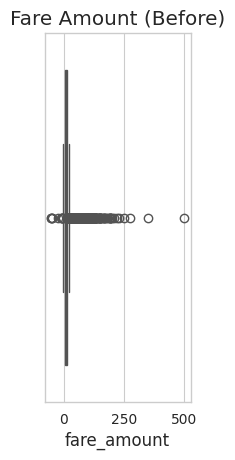

In [17]:
plt.subplot(1,3,1)
sns.boxplot(x=df['fare_amount'])                           # Boxplot for fare amount
plt.title('Fare Amount (Before)')


Text(0.5, 1.0, 'Distance (Before)')

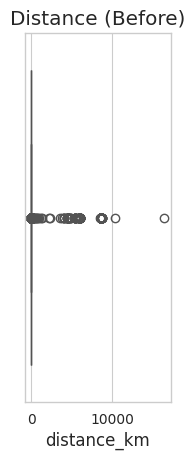

In [18]:

plt.subplot(1,3,2)
sns.boxplot(x=df['distance_km'])                           # Boxplot for distance
plt.title('Distance (Before)')


Text(0.5, 1.0, 'Passenger Count (Before)')

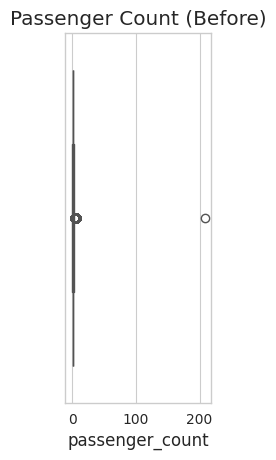

In [19]:
plt.subplot(1,3,3)
sns.boxplot(x=df['passenger_count'])                       # Boxplot for passenger count
plt.title('Passenger Count (Before)')


In [20]:
plt.tight_layout()                                         # Adjust layout to avoid overlapping
plt.show()                                                 # Display plots


<Figure size 640x480 with 0 Axes>

In [21]:
print("\n--- Removing Outliers using IQR ---")

def remove_outliers_iqr(df, column, min_value=None):
    Q1 = df[column].quantile(0.25)                  # 25th percentile
    Q3 = df[column].quantile(0.75)                  # 75th percentile
    IQR = Q3 - Q1                                   # Interquartile range (IQR)
    lower = Q1 - 1.5 * IQR                          # Lower bound
    upper = Q3 + 1.5 * IQR                          # Upper bound
    if min_value is not None:                       # If minimum threshold is given
        lower = max(lower, min_value)               # Ensure lower bound is not below logical min
    print(f"{column}: removing outside [{lower:.2f}, {upper:.2f}]")  # Display removal range
    return df[(df[column] >= lower) & (df[column] <= upper)]  # Filter data within range



--- Removing Outliers using IQR ---


In [22]:
# Apply outlier removal on important columns
df = remove_outliers_iqr(df, 'fare_amount', min_value=0)
df = remove_outliers_iqr(df, 'distance_km', min_value=0)
df = remove_outliers_iqr(df, 'passenger_count', min_value=1)


fare_amount: removing outside [0.00, 22.25]
distance_km: removing outside [0.00, 6.46]
passenger_count: removing outside [1.00, 3.50]


In [23]:
# Ensure passenger count is integer type
df['passenger_count'] = df['passenger_count'].astype(int)



In [24]:

print(f"Dataset shape after outlier removal: {df.shape}")   # Show resulting dataset shape


Dataset shape after outlier removal: (154228, 9)


In [25]:
plt.figure(figsize=(15,5))

<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

Text(0.5, 1.0, 'Fare Amount (After)')

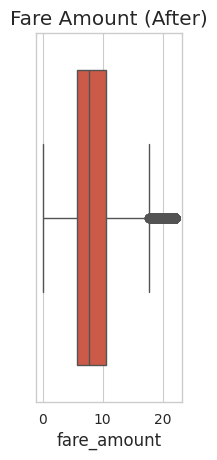

In [26]:
plt.subplot(1,3,1)
sns.boxplot(x=df['fare_amount'])
plt.title('Fare Amount (After)')


Text(0.5, 1.0, 'Distance (After)')

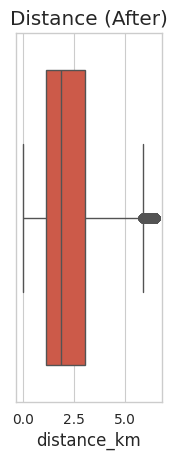

In [27]:
plt.subplot(1,3,2)
sns.boxplot(x=df['distance_km'])
plt.title('Distance (After)')


Text(0.5, 1.0, 'Passenger Count (After)')

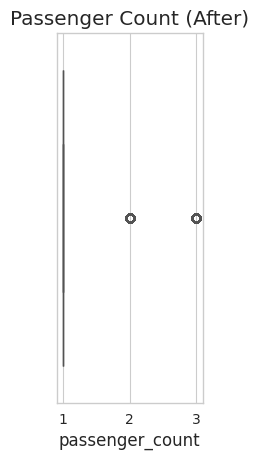

In [28]:
plt.subplot(1,3,3)
sns.boxplot(x=df['passenger_count'])
plt.title('Passenger Count (After)')


In [29]:
plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>


--- Checking Correlation ---


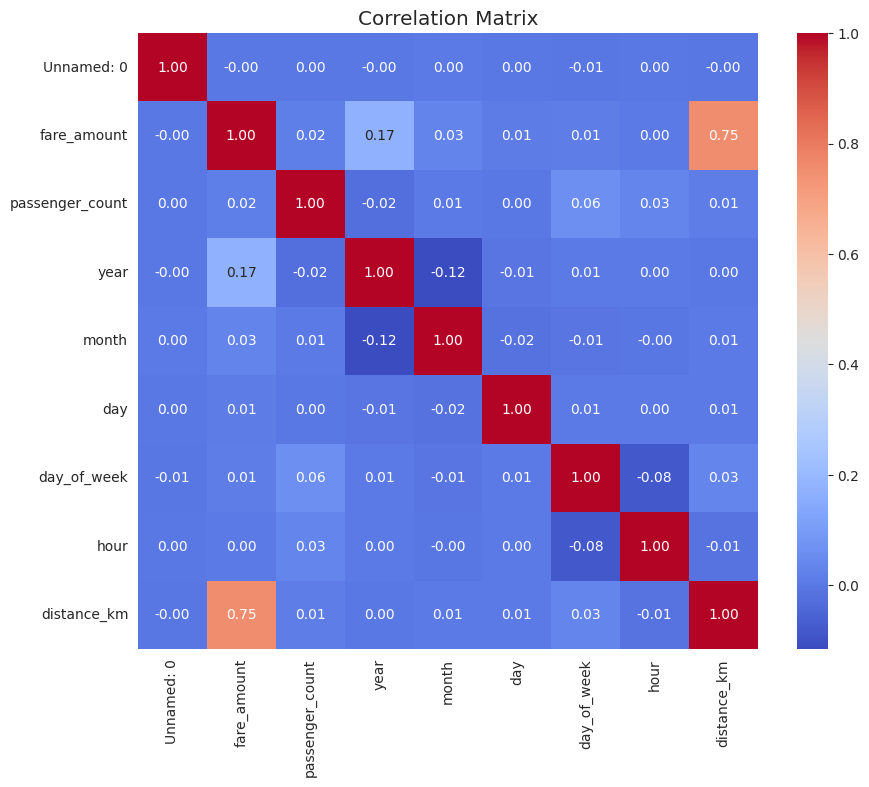

In [30]:
print("\n--- Checking Correlation ---")

plt.figure(figsize=(10,8))                              # Define plot size
sns.heatmap(df.corr(numeric_only=True),                 # Compute correlation matrix
            annot=True, cmap='coolwarm', fmt=".2f")     # Annotate values and use color scale
plt.title('Correlation Matrix')                         # Add title
plt.show()  

In [31]:
features = ['passenger_count','distance_km','year','month','day','day_of_week','hour']  # Independent variables
target = 'fare_amount'                                                                     # Dependent variable

X = df[features]                     # Feature matrix (input)
y = df[target]                       # Target vector (output)


In [32]:
# ==========================================
# 🔹 Splitting Dataset into Training and Testing Sets
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)   # 80% train, 20% test split, fixed random seed for reproducibility

print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")  # Display split sizes


Training samples: 123382, Testing samples: 30846


In [33]:
# ==========================================
# 🔹 Model Training (Linear Regression & Random Forest)
# ==========================================

linear_model = LinearRegression().fit(X_train, y_train)             # Train Linear Regression model
random_forest_model = RandomForestRegressor(                        # Initialize Random Forest model
    n_estimators=100,            # Number of decision trees
    random_state=42,             # Random seed for consistency
    n_jobs=-1                    # Use all CPU cores for faster training
).fit(X_train, y_train)          # Train model on training data

print("Model trained")            # Confirm training complete


Model trained


In [34]:
# ==========================================
# 🔹 Model Evaluation Function
# ==========================================

def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)                         # Predict fares for test data
    r2 = r2_score(y_test, y_pred)                          # Calculate R² (coefficient of determination)
    mae = mean_absolute_error(y_test, y_pred)              # Mean Absolute Error
    mse = mean_squared_error(y_test, y_pred)               # Mean Squared Error
    rmse = np.sqrt(mse)                                    # Root Mean Squared Error
    print(f"\n{name}: R2={r2:.4f}, MAE={mae:.4f}, MSE={mse:.4f}, RMSE={rmse:.4f}")  # Display metrics
    return y_pred, r2, mae, rmse                           # Return results for comparison


In [35]:
# Evaluate both models
y_pred_lr, lr_r2, lr_mae, lr_rmse = evaluate_model(linear_model, X_test, y_test, "Linear Regression")
y_pred_rf, rf_r2, rf_mae, rf_rmse = evaluate_model(random_forest_model, X_test, y_test, "Random Forest")



Linear Regression: R2=0.6049, MAE=1.6460, MSE=5.4745, RMSE=2.3398

Random Forest: R2=0.6600, MAE=1.5310, MSE=4.7118, RMSE=2.1707


In [36]:
# ==========================================
# 🔹 Model Comparison
# ==========================================

print("\n--- Model Comparison ---")

if rf_rmse < lr_rmse:                                     # Compare RMSE values of both models
    print("Random Forest performs better (lower RMSE).")   # Random Forest better
else:
    print("Linear Regression performs better (lower RMSE).")  # Linear Regression better



--- Model Comparison ---
Random Forest performs better (lower RMSE).


In [37]:
# ==========================================
# 🔹 Visual Comparison: Actual vs Predicted Fares
# ==========================================

plt.figure(figsize=(8,6))                               # Define figure size


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

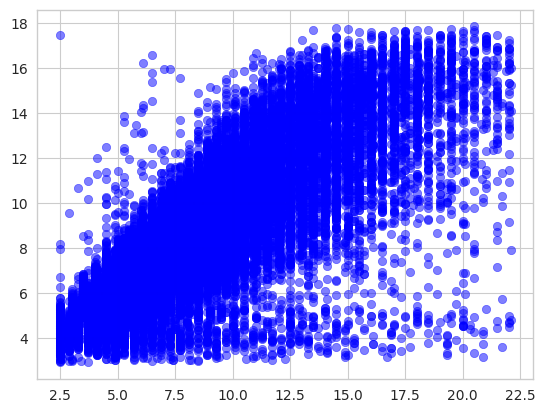

In [38]:
plt.scatter(y_test, y_pred_lr, alpha=0.5,               # Scatter plot for Linear Regression predictions
            label="Linear Regression", color='blue')


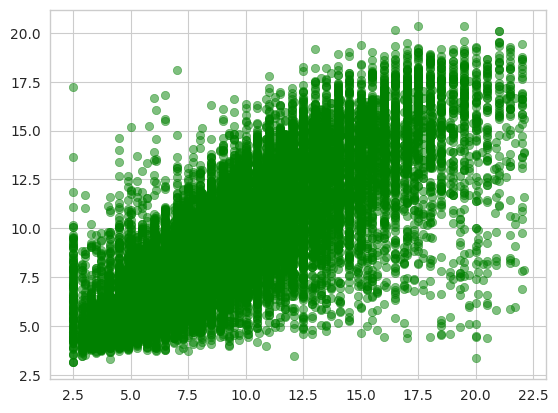

In [39]:
plt.scatter(y_test, y_pred_rf, alpha=0.5,               # Scatter plot for Random Forest predictions
            label="Random Forest", color='green')


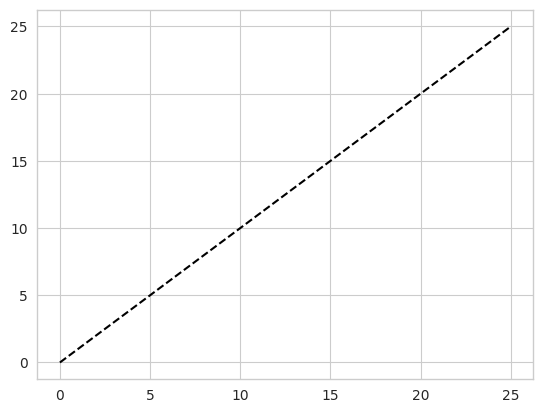

In [40]:
plt.plot([0,25],[0,25],'k--', label="Perfect Fit")      # Reference line showing perfect prediction


/tmp/ipykernel_7254/2217207486.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()                                            # Add legend


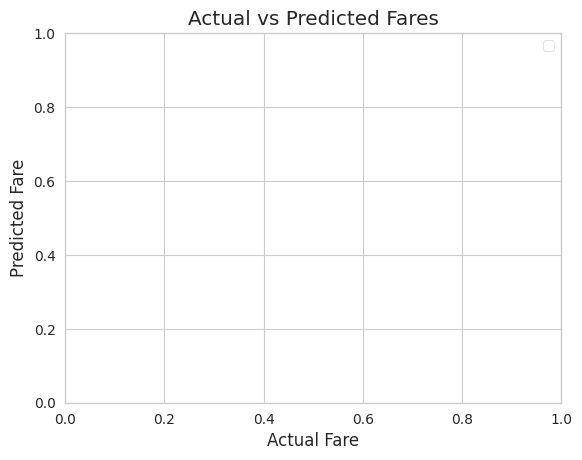

In [41]:
plt.xlabel("Actual Fare")                               # X-axis label
plt.ylabel("Predicted Fare")                            # Y-axis label
plt.legend()                                            # Add legend
plt.title("Actual vs Predicted Fares")                  # Plot title
plt.show()                                              # Display plot


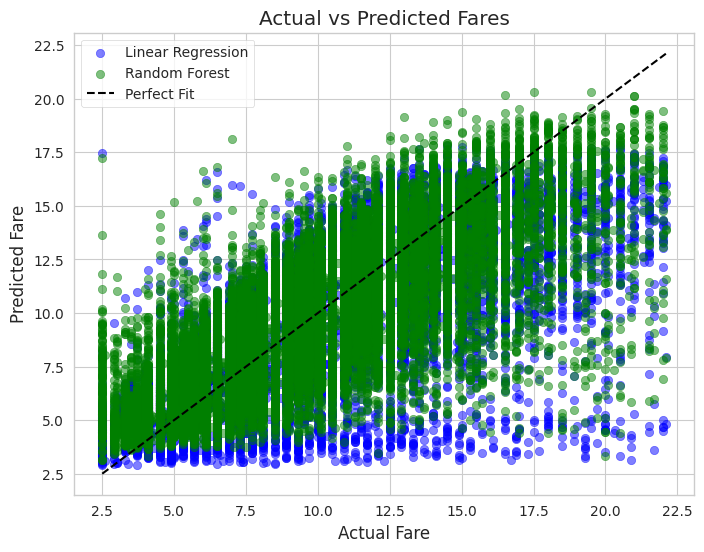

In [42]:
plt.figure(figsize=(8,6))

# Scatter plot for Linear Regression predictions
plt.scatter(y_test, y_pred_lr, alpha=0.5, color='blue', label='Linear Regression')

# Scatter plot for Random Forest predictions
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='green', label='Random Forest')

# Reference line for perfect fit
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', label='Perfect Fit')

plt.xlabel("Actual Fare")         # X-axis label
plt.ylabel("Predicted Fare")      # Y-axis label
plt.title("Actual vs Predicted Fares")   # Title
plt.legend()                      # ✅ Show legend
plt.show()                        # Display plot
